In [ ]:
# EDA Retail Sales Analysis


In [3]:
# Importing required Python Labraries
import pandas as pd
import matplotlib.pyplot as plt


In [26]:
# Loadiing data set
df = pd.read_csv("RetailSalesData.csv")

# Performing Initial Inspection on Data Set
print(df.shape)
df.isnull().sum()

(9800, 18)


Row ID            0
Order ID          0
Order Date        0
Ship Date         0
Ship Mode         0
Customer ID       0
Customer Name     0
Segment           0
Country           0
City              0
State             0
Postal Code      11
Region            0
Product ID        0
Category          0
Sub-Category      0
Product Name      0
Sales             0
dtype: int64

In [27]:
#   After performig some initial operation on Data Set. We understand 
#   that the Data Set Contain 9800 rows and 18 columns.And there 11 
#   null values in Postal Code Column


In [28]:
#Descriptive Statics
print(df[['Sales']].describe())
print(df[['Sales']].median())
print(df[['Sales']].mode())

              Sales
count   9800.000000
mean     230.769059
std      626.651875
min        0.444000
25%       17.248000
50%       54.490000
75%      210.605000
max    22638.480000
Sales    54.49
dtype: float64
   Sales
0  12.96


In [29]:
# In Data Set.By using describe method we get two know that mean=230.769059,
# median =54.49, Standard Deviation=626.651875,Mode = 12.96

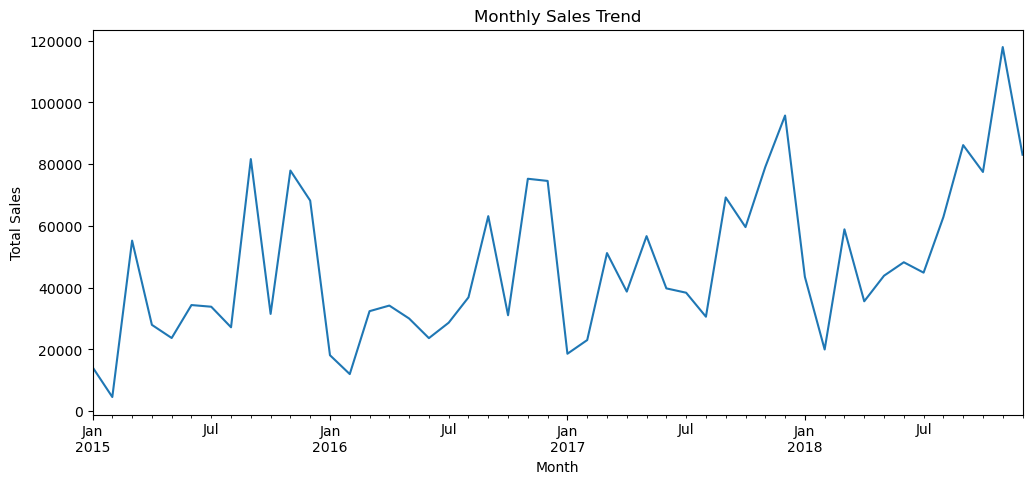

In [30]:
# Time Series Monthly Analysis
# For Time Series Analysis First we convert Data type of Order_Date Column to Date time
df['Order Date']=pd.to_datetime(df['Order Date'],dayfirst=True)

monthly_sales = df.groupby(df['Order Date'].dt.to_period('M'))['Sales'].sum()

monthly_sales.plot(figsize=(12,5))
plt.title('Monthly Sales Trend')
plt.xlabel('Month')
plt.ylabel('Total Sales')
plt.show()

In [31]:
#Observation
# From the above Monthly Analysis line chart, we can see that total sales fluctuated throughout the period. 
# However, the overall trend is increasing, and the highest sales were recorded in the second
# half of 2018. This indicates that the business is experiencing growth in sales over time.

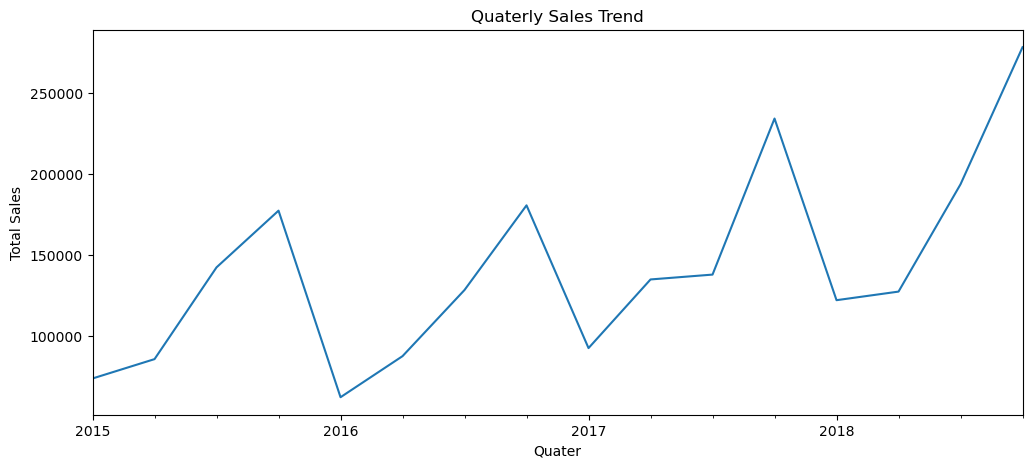

In [32]:
# Time Series Quaterly Analysis
quaterly_sales = df.groupby(df['Order Date'].dt.to_period('Q'))['Sales'].sum()

quaterly_sales.plot(figsize=(12,5))
plt.title('Quaterly Sales Trend')
plt.xlabel('Quater')
plt.ylabel('Total Sales')
plt.show()

In [33]:
#Observation

# The quarterly sales chart shows that sales usually increase at the beginning of each year and 
# decrease at the end of the year. The growth in 2015 and 2016 was similar, but sales started 
# growing faster from 2017. In 2018, the business recorded the highest growth compared to previous years. 
# This shows that the business is expanding and its sales are increasing over time.Based on the pattern
# observed in previous years, sales may decline again towards the end of 2018.


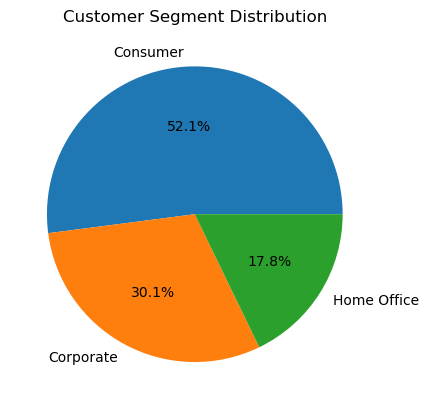

In [34]:
#NOTE :- Because Dataset does not contain demographic attributes
         #Instead, customer segmentation analysis was conducted using the available Segment field.

segment_sales = df.groupby('Segment')['Sales'].sum()

df['Segment'].value_counts().plot(kind='pie', autopct='%1.1f%%')
plt.title('Customer Segment Distribution')
plt.ylabel('')
plt.show()

In [35]:
#Observation

#    The Consumer segment has the highest share of customers (52.1%), followed by Corporate (30.1%) 
#    and Home Office (17.8%). This shows that most customers belong to the Consumer segment, making 
#    it the business's primary customer group

In [36]:
#Producr Analysis

top_products = df.groupby('Product Name')['Sales'].sum().sort_values(ascending=False).head(10)
print(top_products)
#Followimg are the top 10 best-selling products

Product Name
Canon imageCLASS 2200 Advanced Copier                                          61599.824
Fellowes PB500 Electric Punch Plastic Comb Binding Machine with Manual Bind    27453.384
Cisco TelePresence System EX90 Videoconferencing Unit                          22638.480
HON 5400 Series Task Chairs for Big and Tall                                   21870.576
GBC DocuBind TL300 Electric Binding System                                     19823.479
GBC Ibimaster 500 Manual ProClick Binding System                               19024.500
Hewlett Packard LaserJet 3310 Copier                                           18839.686
HP Designjet T520 Inkjet Large Format Printer - 24" Color                      18374.895
GBC DocuBind P400 Electric Binding System                                      17965.068
High Speed Automatic Electric Letter Opener                                    17030.312
Name: Sales, dtype: float64


In [37]:
#Product category

category_sales = df.groupby('Category')['Sales'].sum()
print(category_sales)

Category
Furniture          728658.5757
Office Supplies    705422.3340
Technology         827455.8730
Name: Sales, dtype: float64


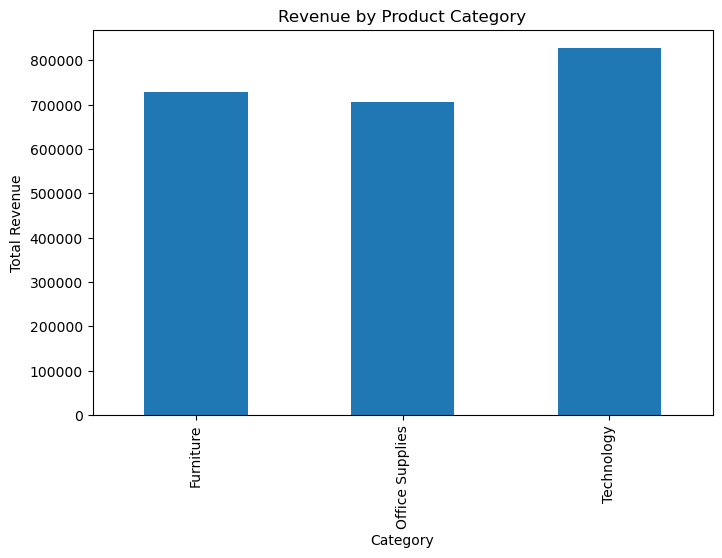

In [38]:
#Revenue by product category (bar chart)
category_sales.plot(kind='bar', figsize=(8,5))

plt.title('Revenue by Product Category')
plt.xlabel('Category')
plt.ylabel('Total Revenue')
plt.show()

In [39]:
#Observation

# Technology generated the highest revenue among all product categories, while Office Supplies generated the lowest.
# Furniture and Office Supplies have similar revenue, but Technology performed better than both. This shows that
# Technology is the most profitable product category for the business.

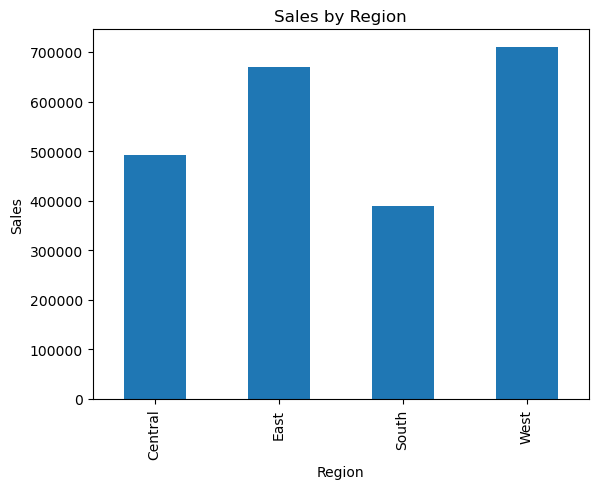

In [40]:
#NOTE :- A Correlation heatmap is not possible.Because Dataset truly has only one business numeric column:Sales
         #Instead  Regional Analysis was conducted 

region_sales = df.groupby('Region')['Sales'].sum()

region_sales.plot(kind='bar')
plt.title('Sales by Region')
plt.xlabel('Region')
plt.ylabel('Sales')
plt.show()

In [41]:
#Observation

#The West region generated the highest sales, while the South region generated the lowest. 
# East also performed well and was close to the West region in sales. This shows that the
# business performs strongest in the West and East regions

In [42]:
#Non-Obvious Insight
#Why?:-This qualifies as a non-obvious insight because it uncovers hidden patterns inside the
       #regional sales totals rather than simply reporting which region has the highest sales.

top_states_region = (
    df.groupby(['Region', 'State'])['Sales'].sum().reset_index()
)

top_5_states = (
    top_states_region.sort_values(['Region', 'Sales'], ascending=[True, False]).groupby('Region').head(5)

)

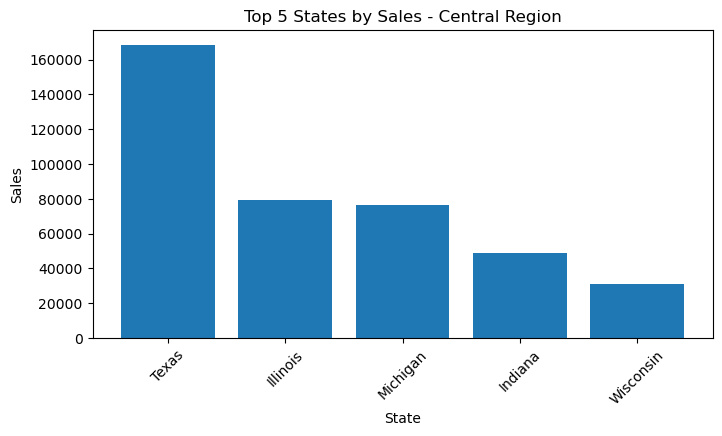

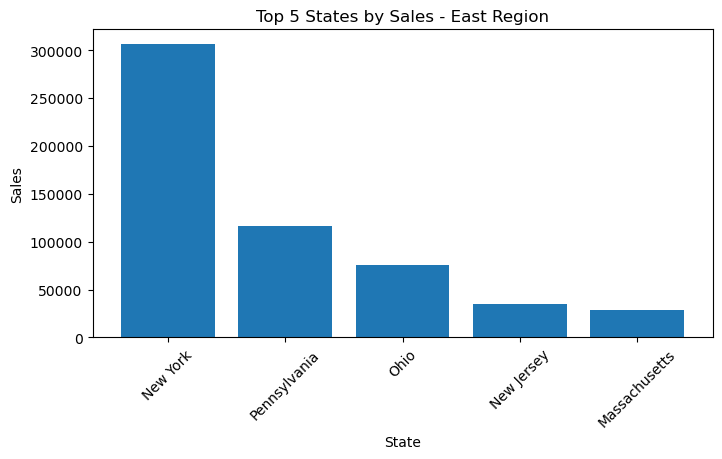

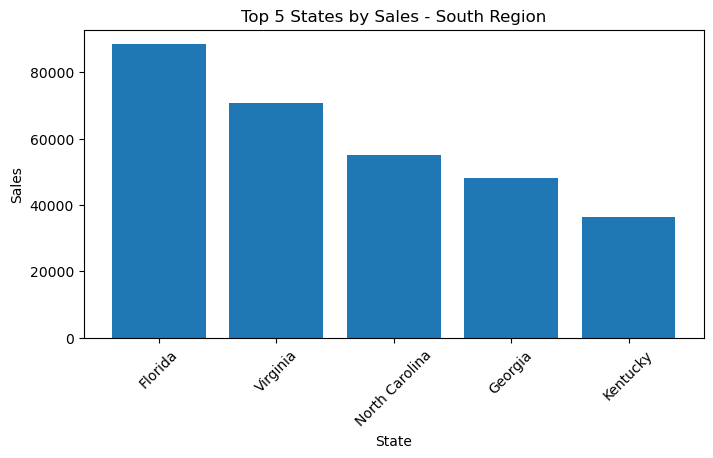

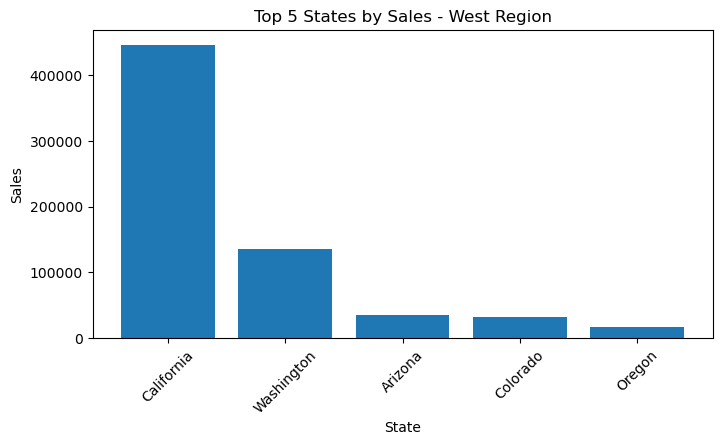

In [43]:
for region in top_5_states['Region'].unique():
    region_data = top_5_states[top_5_states['Region'] == region]

    plt.figure(figsize=(8,4))
    plt.bar(region_data['State'], region_data['Sales'])
    plt.title(f'Top 5 States by Sales - {region} Region')
    plt.xlabel('State')
    plt.ylabel('Sales')
    plt.xticks(rotation=45)
    plt.show()

In [44]:
#Observation

# The top-performing states are generally large economic and population centers, which results
# in higher customer demand and greater sales compared to other states in their regions

In [45]:
#Conclusion

# Overall, the analysis indicates that Technology products generate the highest sales. Sales are strongest
# in states with larger populations and major economic centers. The Consumer segment accounts for 52.1% of
# customers, making it the largest customer group and a major contributor to the sales.

#Suggestions 

# 1.Focus more on the states that already generate strong sales, as they have the potential to bring
#   even more revenue.
# 2.Run special offers and marketing campaigns in states with lower sales to attract more customers
#   and improve performance.
# 3.Keep popular products well-stocked and promote them regularly since they contribute the most to 
#   overall sales.
